# Cinemática del robot industrial ABB IRB140

El IRB140 es un robot antropomórfico de 6 grados de libertad utilizado principalmente en tareas de ensamblaje, manipulación y soldadura. Su arquitectura presenta tres articulaciones de hombro y tres de muñeca, permitiendo alcanzar poses complejas en el espacio 3D con orientación arbitraria.

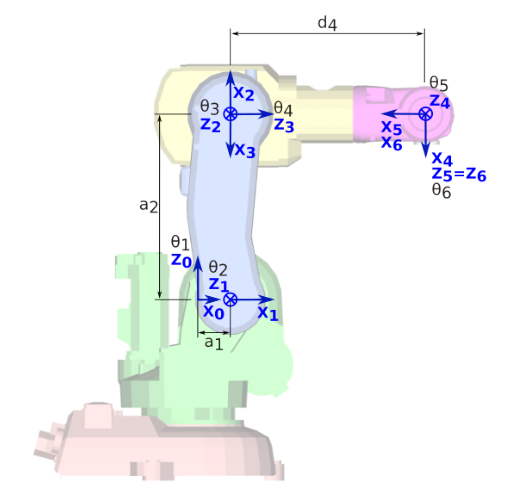


In [ ]:
import numpy as np

def fk_irb140(q):
    """
    Cinemática directa del ABB IRB140.

    Parámetros
    ----------
    q : array-like (6,)
        Variables articulares [q1 ... q6]

    Retorna
    -------
    POSE : ndarray (4,4)
    conf : ndarray (3,)
    """

    q = np.asarray(q)

    # Parámetros DH fijos (m y rad)
    a = np.array([0.070, 0.360, 0, 0, 0, 0])
    d = np.array([0, 0, 0, 0.380, 0, 0])
    alpha = np.array([-np.pi/2, 0, np.pi/2, -np.pi/2, np.pi/2, 0])

    POSE = np.eye(4)

    # Producto de matrices homogéneas
    for i in range(6):
        A = np.array([
            [np.cos(q[i]), -np.sin(q[i])*np.cos(alpha[i]),  np.sin(q[i])*np.sin(alpha[i]), a[i]*np.cos(q[i])],
            [np.sin(q[i]),  np.cos(q[i])*np.cos(alpha[i]), -np.cos(q[i])*np.sin(alpha[i]), a[i]*np.sin(q[i])],
            [0,             np.sin(alpha[i]),               np.cos(alpha[i]),              d[i]],
            [0,             0,                              0,                             1]
        ])
        POSE = POSE @ A

    # Vector de configuración (necesario para IK: identifica soluciones múltiples)
    # conf[0]: hombro (+1/-1 según posición del brazo)
    # conf[1]: codo (+1/-1 según doblez)
    # conf[2]: muñeca (+1/-1 según orientación)
    conf = np.zeros(3)

    conf[0] = np.sign(d[3]*np.sin(q[1]+q[2]) + a[1]*np.cos(q[1]) + a[0])
    conf[1] = np.sign(np.cos(q[2]))
    conf[2] = np.sign(q[4])

    # Evitar ceros
    conf[conf == 0] = 1

    return POSE, conf.astype(int)


In [ ]:
def ik_irb140(POSE, conf, q1_actual=0.0, q4_actual=0.0):
    """
    Cinemática inversa del ABB IRB140.

    Parámetros
    ----------
    POSE : ndarray (4,4)
    conf : array-like (3,)
        [hombro, codo, muñeca] = ±1
    q1_actual : float
    q4_actual : float

    Retorna
    -------
    q : ndarray (6,)
    status : int
        0 = OK, -1 = error
    """

    status = -1

    # DH
    a = np.array([0.070, 0.360, 0, 0, 0, 0])
    d = np.array([0, 0, 0, 0.380, 0, 0])
    alpha = np.array([-np.pi/2, 0, np.pi/2, -np.pi/2, np.pi/2, 0])

    q = np.zeros(6)
    conf = np.asarray(conf)

    # -------------------------
    # POSICIÓN: q1, q2, q3 (cinemática de brazo planar equivalente)
    # -------------------------
    px, py, pz = POSE[0:3, 3]

    # q1: ángulo de rotación alrededor del eje z (hombro)
    # Singularidad cuando la muñeca está sobre el eje z
    if abs(px) < 1e-9 and abs(py) < 1e-9:
        q[0] = q1_actual
    else:
        q[0] = np.arctan2(conf[0]*py, conf[0]*px)

    # q3: problema plano 2D (muñeca en el plano rotado por q1)
    # Ley de cosenos: resuelve el ángulo del codo
    s3 = ((px*np.cos(q[0]) + py*np.sin(q[0]) - a[0])**2 + pz**2 - a[1]**2 - d[3]**2) / (2*a[1]*d[3])

    if abs(s3) > 1:
        print("ERROR: Punto no alcanzable")
        return q, status

    # conf[1] selecciona codo arriba (+1) o abajo (-1)
    c3 = conf[1]*np.sqrt(1 - s3**2)
    q[2] = np.arctan2(s3, c3)

    # q2: ángulo de hombro → resolver posición de muñeca
    # Cinematica inversa de 2 eslabones: a1, d3 (prisma), codo q2
    s2 = (px*np.cos(q[0]) + py*np.sin(q[0]) - a[0])*(d[3]*np.cos(q[2])) - (d[3]*np.sin(q[2]) + a[1])*pz
    c2 = (px*np.cos(q[0]) + py*np.sin(q[0]) - a[0])*(d[3]*np.sin(q[2]) + a[1]) + (d[3]*np.cos(q[2]))*pz
    q[1] = np.arctan2(s2, c2)

    # -------------------------
    # ORIENTACIÓN: q4, q5, q6 (cinemática de muñeca esférica)
    # -------------------------
    # Matriz de rotación base-eslabón 3
    R_30 = np.eye(3)

    for i in range(3):
        A = np.array([
            [np.cos(q[i]), -np.sin(q[i])*np.cos(alpha[i]),  np.sin(q[i])*np.sin(alpha[i])],
            [np.sin(q[i]),  np.cos(q[i])*np.cos(alpha[i]), -np.cos(q[i])*np.sin(alpha[i])],
            [0,             np.sin(alpha[i]),               np.cos(alpha[i])]
        ])
        R_30 = R_30 @ A

    # Matriz de rotación relativa: muñeca respecto a eslabón 3
    R_60 = POSE[:3, :3]
    R_63 = R_30.T @ R_60

    # q5: ángulo de pitch de la muñeca (robustez numérica)
    c5 = R_63[2, 2]
    c5 = np.clip(c5, -1.0, 1.0)  # Protección: evita acos(>1) por errores de punto flotante

    q[4] = np.arctan2(conf[2]*np.sqrt(1 - c5**2), c5)

    # Singularidad muñeca: q4 y q6 indeterminados (desacople de roll-yaw)
    if abs(R_63[1,2]) < 1e-9 and abs(R_63[0,2]) < 1e-9:
        q[3] = q4_actual
        q[5] = np.arctan2(R_63[1,0], R_63[0,0]) - q4_actual
    else:
        # q4: ángulo de roll
        s4 = conf[2]*R_63[1,2]
        c4 = conf[2]*R_63[0,2]
        q[3] = np.arctan2(s4, c4)

        # q6: ángulo de yaw
        s6 = conf[2]*R_63[2,1]
        c6 = -conf[2]*R_63[2,0]
        q[5] = np.arctan2(s6, c6)

    # Limpieza numérica: elimina ruido en ceros
    q[np.abs(q) < 1e-9] = 0.0

    return q, 0


In [ ]:
# Configuración de la figura
q_des = np.array([0, -np.pi/2, np.pi, 0, np.pi/2, 0])

print("q_des:")
print(q_des)

# Forward: obtener POSE deseada y detectar configuración
POSE_d, conf = fk_irb140(q_des)

print("POSE: ")
print(POSE_d)
print("\nconf (hombro, codo, muñeca):")
print(conf)

# Inverse: recuperar q desde POSE
q_rec, status = ik_irb140(POSE_d, conf)

print("\nq_rec:")
print(q_rec)
print("status:", status)

# Verificación: FK(q_rec) debe coincidir con POSE_d
POSE_rec, _ = fk_irb140(q_rec)

print("\n¿POSE ≈ POSE_rec?:", np.allclose(POSE_d, POSE_rec, atol=1e-6))
print("Error en q:", q_des - q_rec)


q_des:
[ 0.         -1.57079633  3.14159265  0.          1.57079633  0.        ]
POSE: 
[[-1.00000000e+00 -7.49879891e-33  1.22464680e-16  4.50000000e-01]
 [ 3.74939946e-33  1.00000000e+00  1.22464680e-16  1.22464680e-18]
 [-1.22464680e-16  1.22464680e-16 -1.00000000e+00  3.60000000e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

conf:
[ 1 -1  1]

q_rec:
[ 0.         -1.57079633  3.14159265  0.          1.57079633  0.        ]
status: 0

¿POSE ≈ POSE_rec?: True
Error en q: [0. 0. 0. 0. 0. 0.]
